In [1]:
import pandas as pd
import numpy as np

import tubesml as tml

import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

from os.path import join, isfile
from os import path, scandir, listdir

In [2]:
def list_all_files(location='../input/', pattern=None, recursive=True):
    """
    This function returns a list of files at a given location (including subfolders)
    
    - location: path to the directory to be searched
    - pattern: part of the file name to be searched (ex. pattern='.csv' would return all the csv files)
    - recursive: boolean, if True the function calls itself for every subdirectory it finds
    """
    subdirectories= [f.path for f in scandir(location) if f.is_dir()]
    files = [join(location, f) for f in listdir(location) if isfile(join(location, f))]
    if recursive:
        for directory in subdirectories:
            files.extend(list_all_files(directory))
    if pattern:
        files = [f for f in files if pattern in f]
    return files

In [4]:
all_files = list_all_files("data/")
all_files

['data/march-machine-learning-mania-2026/MTeams.csv',
 'data/march-machine-learning-mania-2026/MNCAATourneyCompactResults.csv',
 'data/march-machine-learning-mania-2026/MSecondaryTourneyCompactResults.csv',
 'data/march-machine-learning-mania-2026/WSecondaryTourneyTeams.csv',
 'data/march-machine-learning-mania-2026/WNCAATourneyCompactResults.csv',
 'data/march-machine-learning-mania-2026/WNCAATourneySlots.csv',
 'data/march-machine-learning-mania-2026/MTeamCoaches.csv',
 'data/march-machine-learning-mania-2026/MRegularSeasonDetailedResults.csv',
 'data/march-machine-learning-mania-2026/MNCAATourneyDetailedResults.csv',
 'data/march-machine-learning-mania-2026/MTeamConferences.csv',
 'data/march-machine-learning-mania-2026/SampleSubmissionStage1.csv',
 'data/march-machine-learning-mania-2026/WNCAATourneySeeds.csv',
 'data/march-machine-learning-mania-2026/MGameCities.csv',
 'data/march-machine-learning-mania-2026/MSecondaryTourneyTeams.csv',
 'data/march-machine-learning-mania-2026/MNC

# Submission files

In [5]:
[col for col in all_files if 'Submission' in col]

['data/march-machine-learning-mania-2026/SampleSubmissionStage1.csv',
 'data/march-machine-learning-mania-2026/SampleSubmissionStage2.csv']

In [8]:
df = pd.read_csv('data/march-machine-learning-mania-2026/SampleSubmissionStage1.csv')
df[['year', 'Team_1', 'Team_2']] = pd.DataFrame(df['ID'].str.split('_').values.tolist(), index=df.index)
df['year'] = pd.to_numeric(df.year)
df.head()

,ID,Pred,year,Team_1,Team_2
0,2022_1101_1102,0.5,2022,1101,1102
1,2022_1101_1103,0.5,2022,1101,1103
2,2022_1101_1104,0.5,2022,1101,1104
3,2022_1101_1105,0.5,2022,1101,1105
4,2022_1101_1106,0.5,2022,1101,1106


In [9]:
df.year.value_counts(dropna=False)

year
2025    131407
2023    130683
2024    129961
2022    127093
Name: count, dtype: int64

In [10]:
df = pd.read_csv('data/march-machine-learning-mania-2026/SampleSubmissionStage2.csv')
df[['year', 'Team_1', 'Team_2']] = pd.DataFrame(df['ID'].str.split('_').values.tolist(), index=df.index)
df['year'] = pd.to_numeric(df.year)
df.year.value_counts(dropna=False)

year
2026    132133
Name: count, dtype: int64

# Teams

In [11]:
[file for file in all_files if 'Teams.csv' in file]

['data/march-machine-learning-mania-2026/MTeams.csv',
 'data/march-machine-learning-mania-2026/WSecondaryTourneyTeams.csv',
 'data/march-machine-learning-mania-2026/MSecondaryTourneyTeams.csv',
 'data/march-machine-learning-mania-2026/WTeams.csv']

In [27]:
def plot_teams(file_name):
    df = pd.read_csv(file_name)
    print(f"{file_name} as the following shape {df.shape}")
    print(df.head())

    if "LastD1Season" in df:
        df['years_in_d1'] = df['LastD1Season'] - df['FirstD1Season']

        df['years_in_d1'].hist(bins=20)
        plt.grid(False)
        plt.title("Distribution number of years in D1")
        plt.show()

        df.FirstD1Season.hist(bins=20, alpha=0.7, label='First Season')
        df.LastD1Season.hist(bins=20, alpha=0.7, label='Last Season')
        plt.grid(False)
        plt.legend()
        plt.title("First and last season in D1 distribution")
        plt.show()

        yr_count = pd.DataFrame({'year': np.arange(1985, 2022)})

        for year in yr_count.year:
            df['is_in'] = 0
            df.loc[(df.FirstD1Season <= year) & (df.LastD1Season >= year), 'is_in'] = 1
            tot_teams = df.is_in.sum()
            yr_count.loc[yr_count.year == year, 'n_teams'] = tot_teams

        yr_count = yr_count.set_index('year')
        yr_count.n_teams.plot()
        plt.title("Number of teams competing per year")
        plt.show()

data/march-machine-learning-mania-2026/MTeams.csv as the following shape (381, 4)
   TeamID     TeamName  FirstD1Season  LastD1Season
0    1101  Abilene Chr           2014          2026
1    1102    Air Force           1985          2026
2    1103        Akron           1985          2026
3    1104      Alabama           1985          2026
4    1105  Alabama A&M           2000          2026


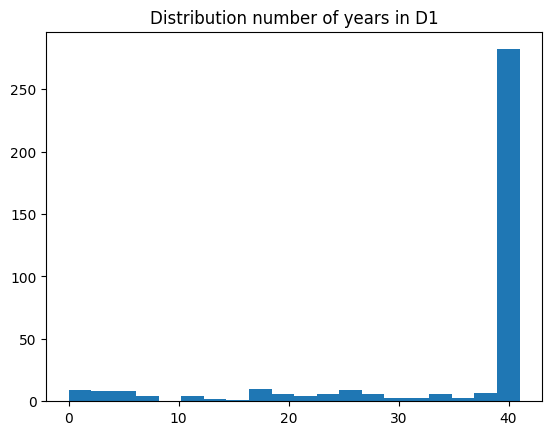

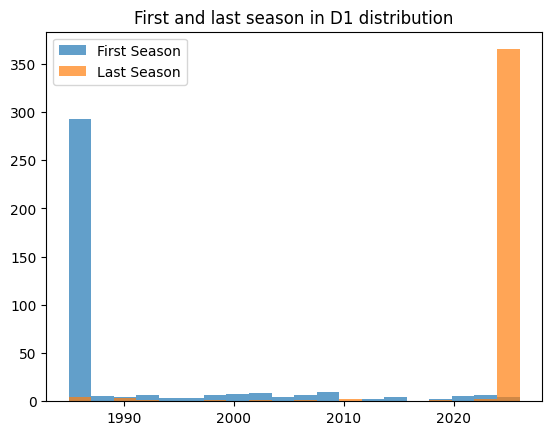

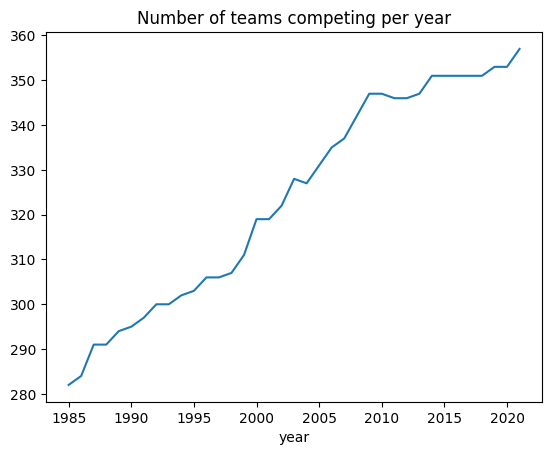

In [28]:
plot_teams('data/march-machine-learning-mania-2026/MTeams.csv')

In [29]:
plot_teams('data/march-machine-learning-mania-2026/WTeams.csv')

data/march-machine-learning-mania-2026/WTeams.csv as the following shape (379, 2)
   TeamID     TeamName
0    3101  Abilene Chr
1    3102    Air Force
2    3103        Akron
3    3104      Alabama
4    3105  Alabama A&M


# Seasons

In [30]:
[file for file in all_files if 'Seasons.csv' in file]

['data/march-machine-learning-mania-2026/MSeasons.csv',
 'data/march-machine-learning-mania-2026/WSeasons.csv']

In [32]:
df = pd.read_csv('data/march-machine-learning-mania-2026/MSeasons.csv')
print(df.shape)
df.head()

(42, 6)


,Season,DayZero,RegionW,RegionX,RegionY,RegionZ
0,1985,10/29/1984,East,West,Midwest,Southeast
1,1986,10/28/1985,East,Midwest,Southeast,West
2,1987,10/27/1986,East,Southeast,Midwest,West
3,1988,11/02/1987,East,Midwest,Southeast,West
4,1989,10/31/1988,East,West,Midwest,Southeast


In [33]:
df = pd.read_csv('data/march-machine-learning-mania-2026/WSeasons.csv')
print(df.shape)
df.head()

(29, 6)


,Season,DayZero,RegionW,RegionX,RegionY,RegionZ
0,1998,10/27/1997,East,Midwest,Mideast,West
1,1999,10/26/1998,East,Mideast,Midwest,West
2,2000,11/01/1999,East,Midwest,Mideast,West
3,2001,10/30/2000,East,Midwest,Mideast,West
4,2002,10/29/2001,East,West,Mideast,Midwest


# RegularSeasonCompactResult

In [34]:
[file for file in all_files if 'RegularSeasonCompact' in file]

['data/march-machine-learning-mania-2026/WRegularSeasonCompactResults.csv',
 'data/march-machine-learning-mania-2026/MRegularSeasonCompactResults.csv']

In [57]:
def _summariesregseason(df):
    df['point_diff'] = df.WScore - df.LScore
    summaries = df[['Season', 
                    'WScore', 
                    'LScore', 
                    'NumOT', 
                    'point_diff']].groupby('Season').agg(['min', 'max', 'mean', 'median'])

    summaries.columns = ['_'.join(col).strip() for col in summaries.columns.values]

    summaries_by = df[['Season', 'WLoc',
                'WScore', 
                'LScore', 
                'NumOT', 
                'point_diff']].groupby(['Season', 'WLoc']).agg(['min', 'max', 'mean', 'median', 'count'])

    summaries_by.columns = ['_'.join(col).strip() for col in summaries_by.columns.values]

    return df, summaries, summaries_by


def plot_regseason_compact(m_file_name, w_file_name):
    df_m = pd.read_csv(m_file_name)
    print(f"{m_file_name} as the following shape {df_m.shape}")
    print(df_m.head())
    df_w = pd.read_csv(w_file_name)
    print(f"{w_file_name} as the following shape {df_w.shape}")
    print(df_w.head())

    df_m, summary_m, summary_m_by = _summariesregseason(df_m)
    df_w, summary_w, summary_w_by = _summariesregseason(df_w)

    fig, ax = plt.subplots(1, 2, figsize=(12,5), sharex=True)
    df_m["point_diff"].hist(bins=30, ax=ax[0], grid=False)
    df_w["point_diff"].hist(bins=30, ax=ax[1], grid=False)
    ax[0].set_title("Point difference - Men")
    ax[1].set_title("Point difference - Women")
    plt.show()

    fig, ax = plt.subplots(2, 2, figsize=(12,10), sharey=True)
    summary_m[[col for col in summary_m.columns if 'WScore' in col and 'sum' not in col]].plot(title="Winning Score - Men", ax=ax[0][0])
    summary_w[[col for col in summary_w.columns if 'WScore' in col and 'sum' not in col]].plot(title="Winning Score - Women", ax=ax[0][1])

    summary_m[[col for col in summary_m.columns if 'LScore' in col and 'sum' not in col]].plot(title="Losing Score - Men", ax=ax[1][0])
    summary_w[[col for col in summary_w.columns if 'LScore' in col and 'sum' not in col]].plot(title="Losing Score - Women", ax=ax[1][1])
    plt.show()

    fig, ax = plt.subplots(2, 2, figsize=(12,10), sharey=True)
    summary_m_by[['WScore_mean']].unstack().plot(title="Winning Score by Homecourt - Men", ax=ax[0][0])
    summary_w_by[['WScore_mean']].unstack().plot(title="Winning Score by Homecourt - Women", ax=ax[0][1])

    summary_m_by[['LScore_mean']].unstack().plot(title="Losing Score by Homecourt - Men", ax=ax[1][0])
    summary_w_by[['LScore_mean']].unstack().plot(title="Losing Score by Homecourt - Women", ax=ax[1][1])
    plt.show()

    fig, ax = plt.subplots(1, 2, figsize=(12,5), sharey=True)
    summary_m[[col for col in summary_m.columns if 'point_diff' in col and 'sum' not in col]].plot(title="Point Difference - Men", ax=ax[0])
    summary_w[[col for col in summary_w.columns if 'point_diff' in col and 'sum' not in col]].plot(title="Point Difference - Women", ax=ax[1])
    plt.show()

    fig, ax = plt.subplots(1, 2, figsize=(12,5), sharey=True)
    summary_m_by[['point_diff_mean']].unstack().plot(title="Point Difference by Homecourt - Men", ax=ax[0])
    summary_w_by[['point_diff_mean']].unstack().plot(title="Point Difference by Homecourt - Women", ax=ax[1])
    plt.show()

    fig, ax = plt.subplots(1, 2, figsize=(12,5), sharey=True)
    summary_m_by[['WScore_count']].unstack().plot(title="Number of Victories by Homecourt - Men", ax=ax[0])
    summary_w_by[['WScore_count']].unstack().plot(title="Number of Victories by Homecourt - Women", ax=ax[1])
    plt.show()

    fig, ax = plt.subplots(1, 2, figsize=(12,5), sharey=True)
    summary_m[['NumOT_mean', 'NumOT_max']].plot(title="Number of Overtime - Men", ax=ax[0])
    summary_w[['NumOT_mean', 'NumOT_max']].plot(title="Number of Overtime - Women", ax=ax[1])
    plt.show()

    

data/march-machine-learning-mania-2026/MRegularSeasonCompactResults.csv as the following shape (196823, 8)
   Season  DayNum  WTeamID  WScore  LTeamID  LScore WLoc  NumOT
0    1985      20     1228      81     1328      64    N      0
1    1985      25     1106      77     1354      70    H      0
2    1985      25     1112      63     1223      56    H      0
3    1985      25     1165      70     1432      54    H      0
4    1985      25     1192      86     1447      74    H      0
data/march-machine-learning-mania-2026/WRegularSeasonCompactResults.csv as the following shape (140825, 8)
   Season  DayNum  WTeamID  WScore  LTeamID  LScore WLoc  NumOT
0    1998      18     3104      91     3202      41    H      0
1    1998      18     3163      87     3221      76    H      0
2    1998      18     3222      66     3261      59    H      0
3    1998      18     3307      69     3365      62    H      0
4    1998      18     3349     115     3411      35    H      0


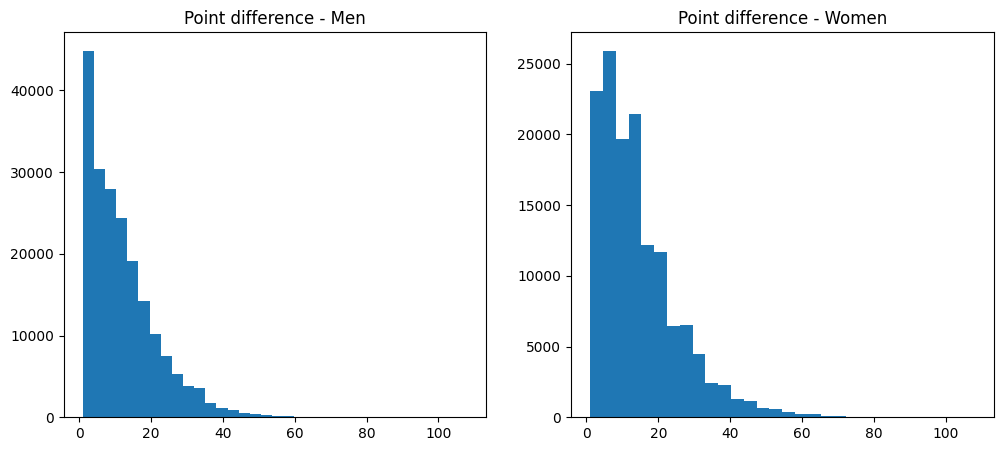

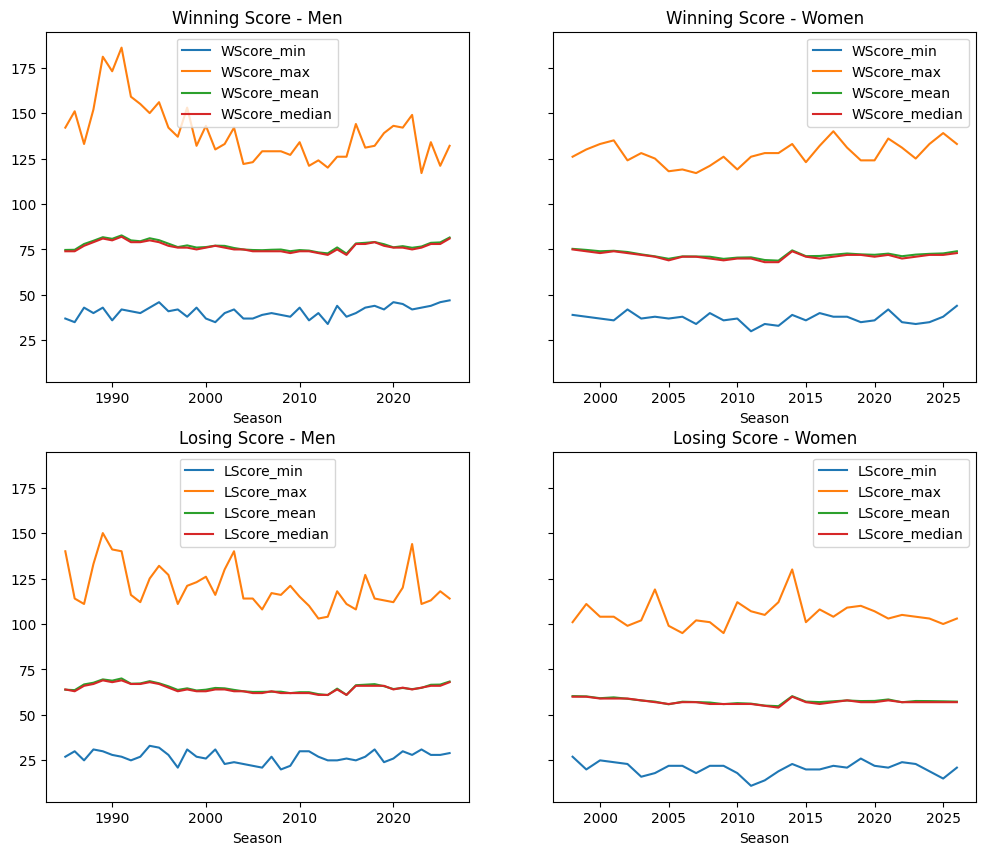

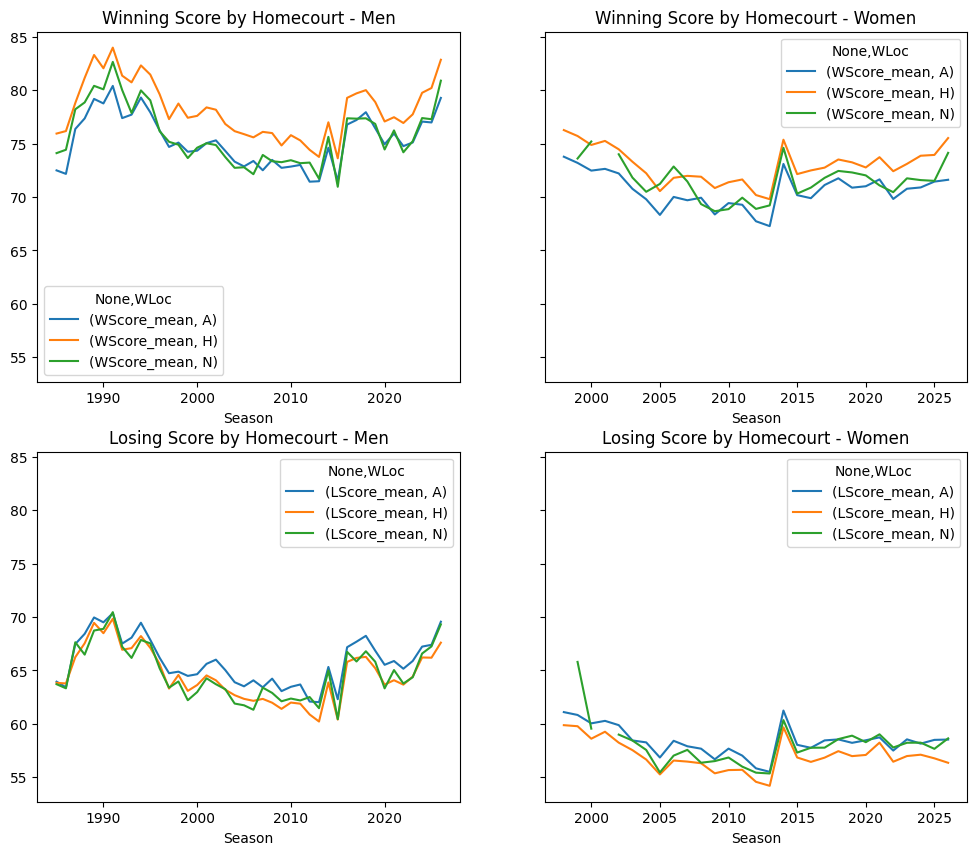

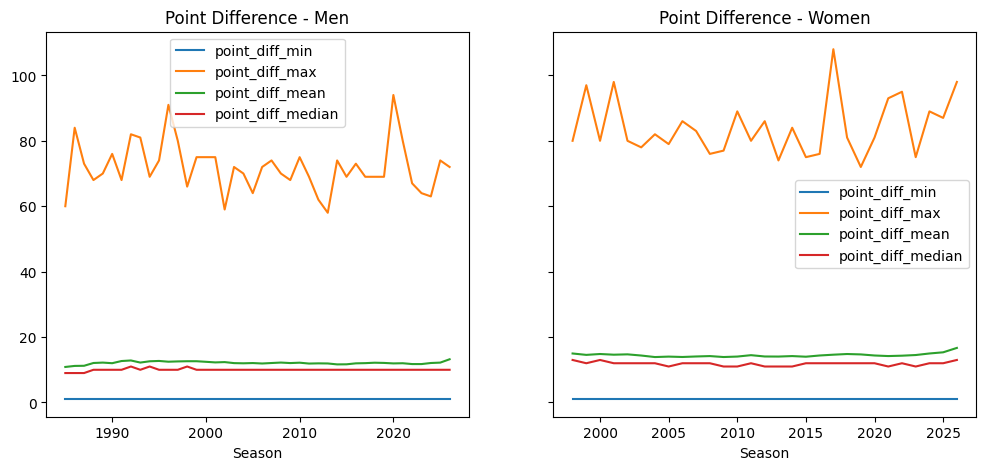

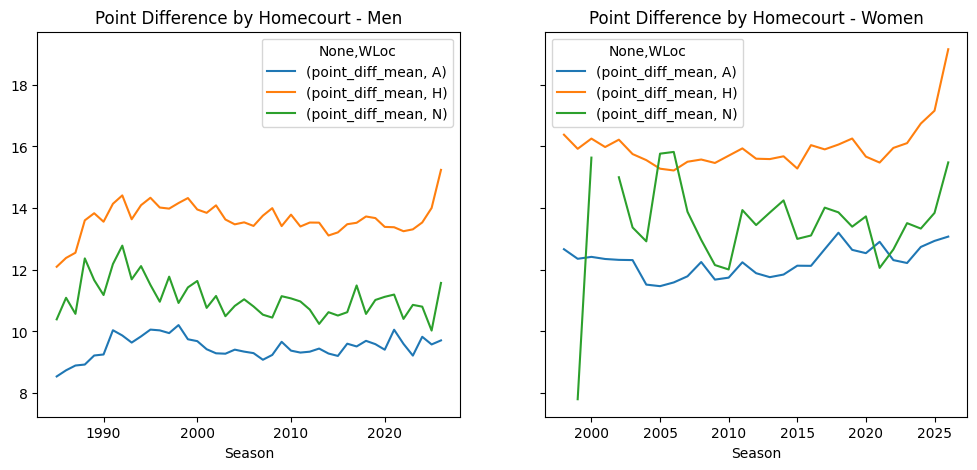

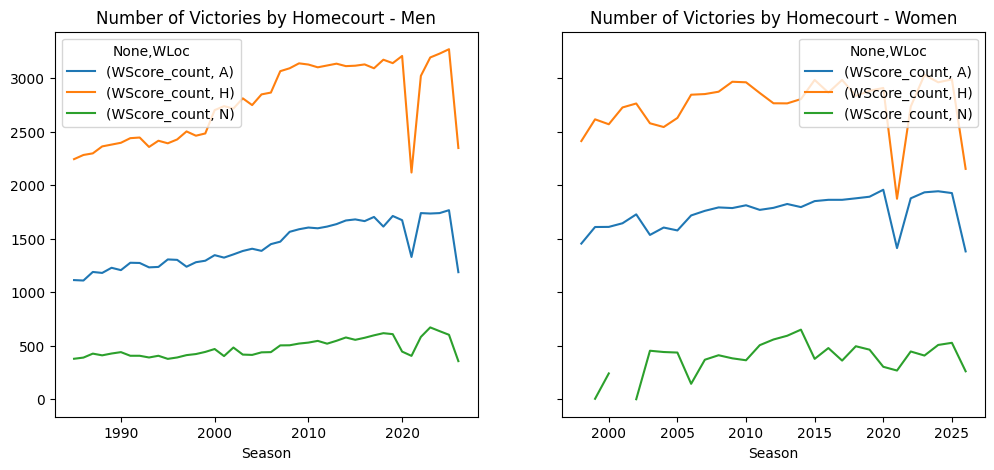

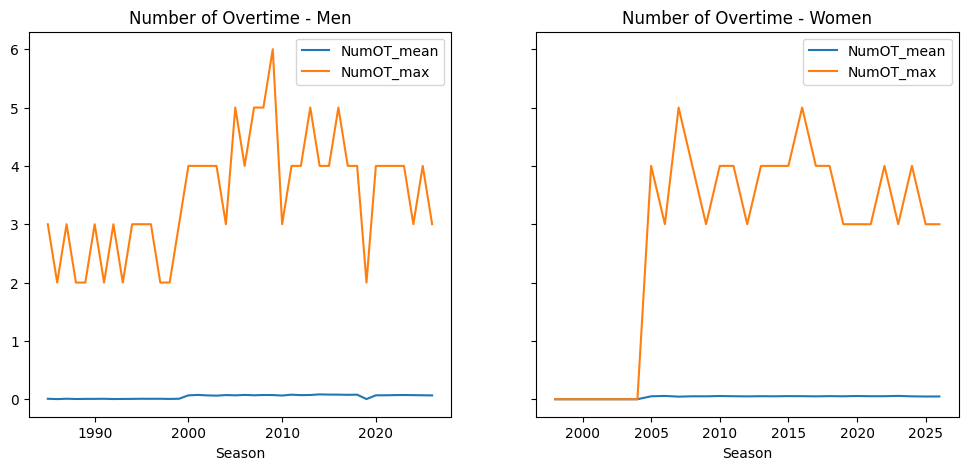

In [58]:
plot_regseason_compact(m_file_name='data/march-machine-learning-mania-2026/MRegularSeasonCompactResults.csv',
                       w_file_name='data/march-machine-learning-mania-2026/WRegularSeasonCompactResults.csv')

# Playoff Compact Result

In [59]:
[file for file in all_files if 'NCAATourneyCompact' in file]

['data/march-machine-learning-mania-2026/MNCAATourneyCompactResults.csv',
 'data/march-machine-learning-mania-2026/WNCAATourneyCompactResults.csv']

data/march-machine-learning-mania-2026/MNCAATourneyCompactResults.csv as the following shape (2585, 8)
   Season  DayNum  WTeamID  WScore  LTeamID  LScore WLoc  NumOT
0    1985     136     1116      63     1234      54    N      0
1    1985     136     1120      59     1345      58    N      0
2    1985     136     1207      68     1250      43    N      0
3    1985     136     1229      58     1425      55    N      0
4    1985     136     1242      49     1325      38    N      0
data/march-machine-learning-mania-2026/WNCAATourneyCompactResults.csv as the following shape (1717, 8)
   Season  DayNum  WTeamID  WScore  LTeamID  LScore WLoc  NumOT
0    1998     137     3104      94     3422      46    H      0
1    1998     137     3112      75     3365      63    H      0
2    1998     137     3163      93     3193      52    H      0
3    1998     137     3198      59     3266      45    H      0
4    1998     137     3203      74     3208      72    A      0


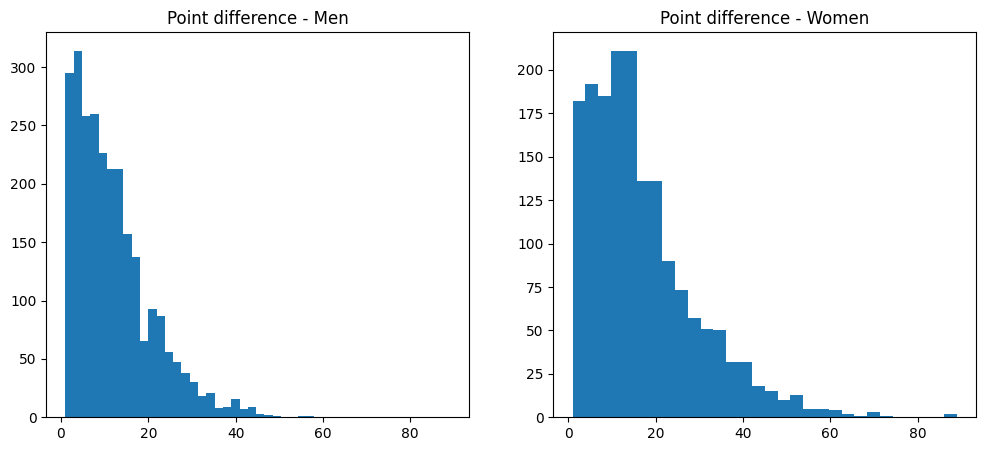

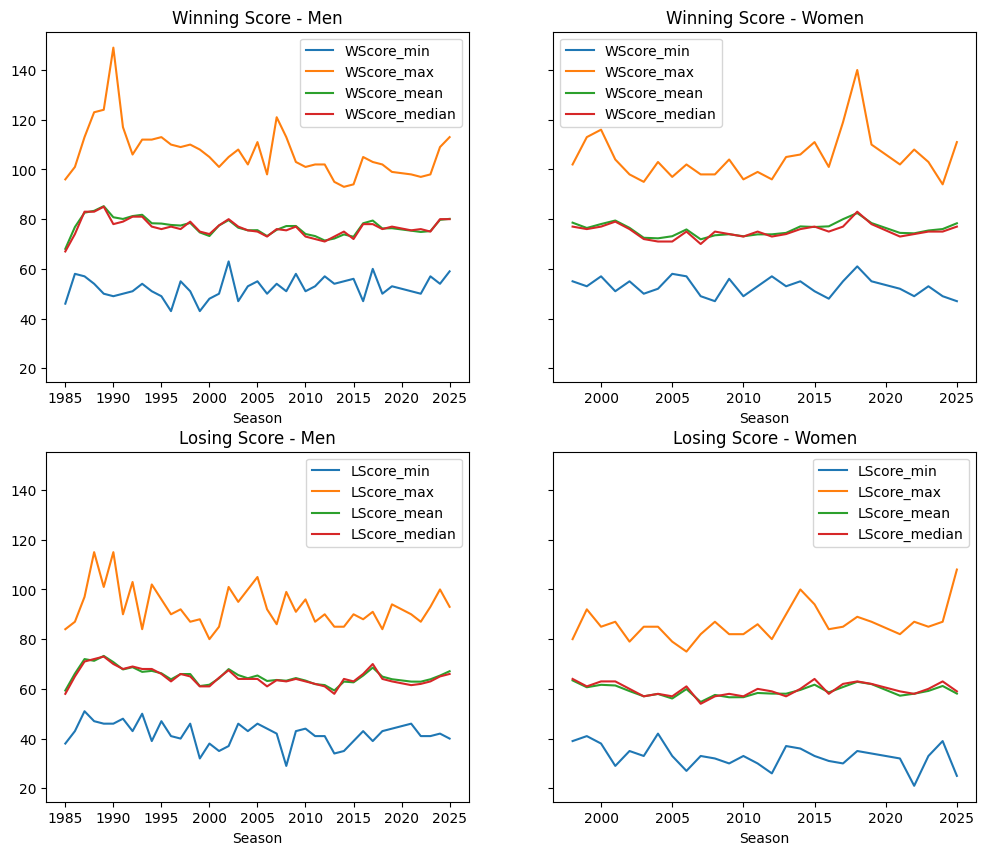

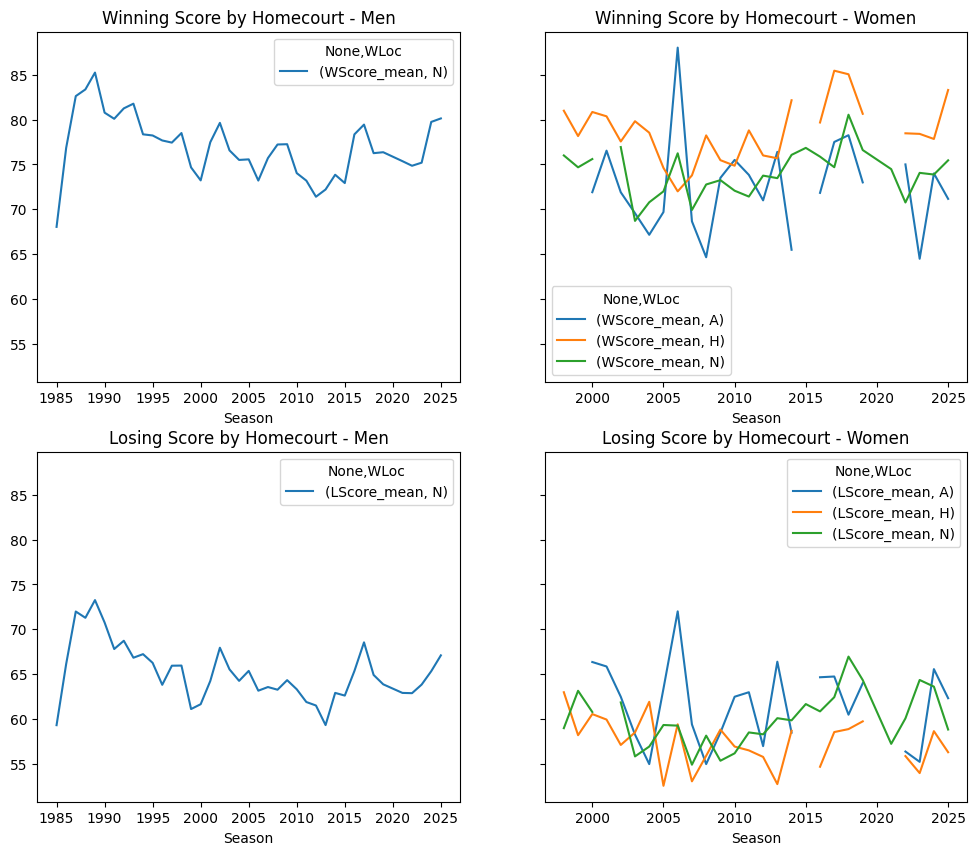

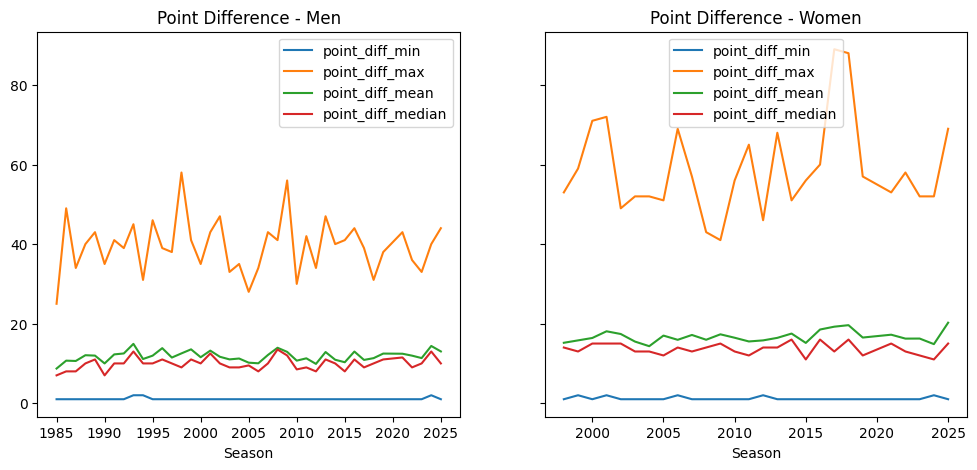

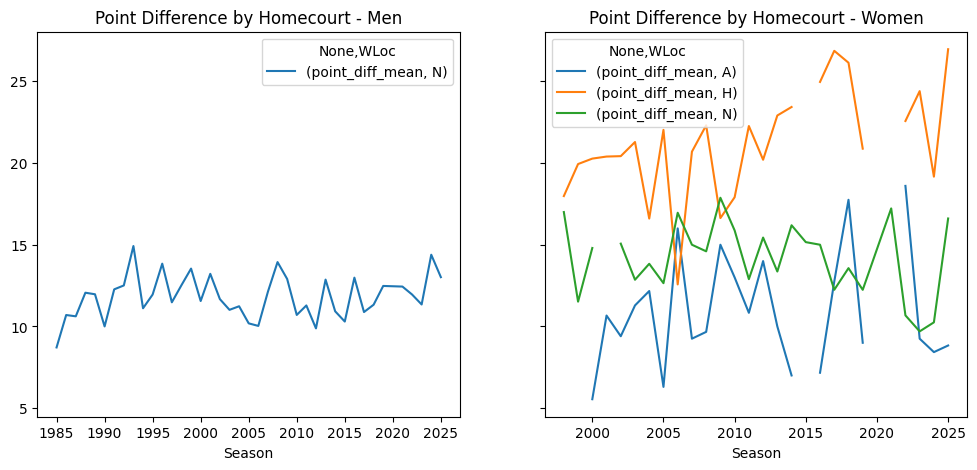

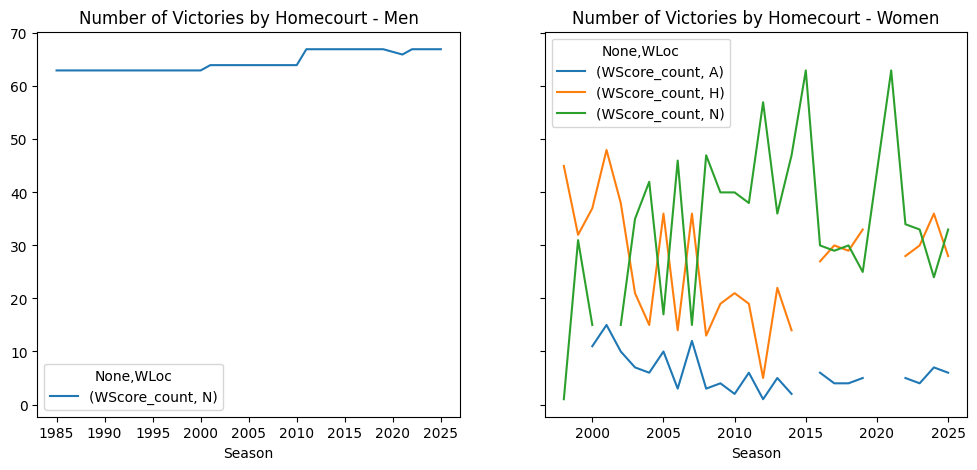

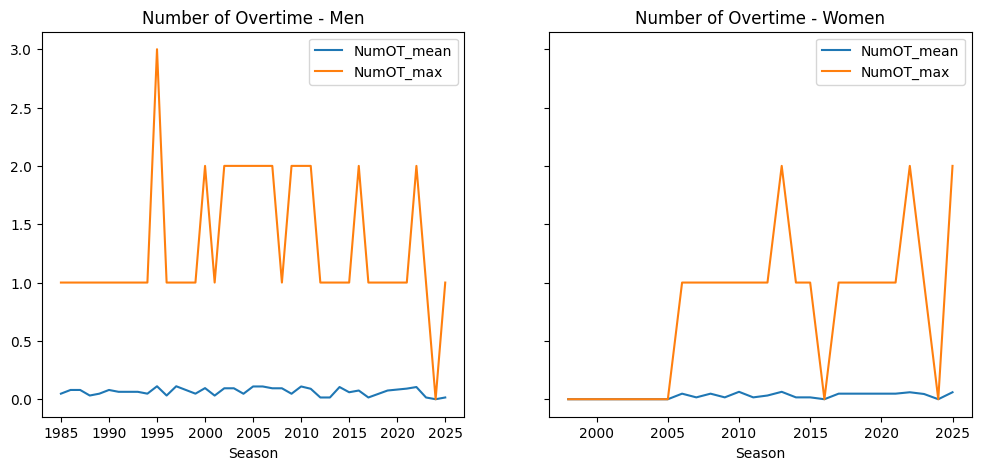

In [60]:
plot_regseason_compact(m_file_name='data/march-machine-learning-mania-2026/MNCAATourneyCompactResults.csv',
                       w_file_name='data/march-machine-learning-mania-2026/WNCAATourneyCompactResults.csv')